# 2D field interpolation

This short tutorial demonstrates how to use `smudgy` to interpolate a particle field to arbitrary coordinates. The following examples are shown:

+ Interpolation of a single __scalar__ field to a regular 2D grid of query points.
+ Interpolation of the scalar field's gradient at the same query points.
+ Computation and interpolation of the divergence and curl of a 2D __vector__ field

`smudgy.utils` offers a helper function {py:func}`~smudgy.utils.create_grid_2d` (similar functions are available for 1D and 3D) to quickly construct equidistant coordinates. However, arbitrary coordinates can also be passed to the relevant methods.

First, let's import all the necessary packages and modules:

In [16]:
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np

import smudgy as sm
from smudgy.utils import create_grid_2d

In [17]:
try:
    plt.style.use('custom')
except:
    pass
%matplotlib inline
%config InlineBackend.figure_format='retina'


## Interpolating a single scalar field

Let's generate a set of particles with (random) 2D positions, weights set to ones, and field values within a periodic box of size 1. As an example we assign each particle $j$ a field value $f_j = f(x_j,y_j)=\sin(2 \pi x_j) \cos(2 \pi y_j)$ depending on their spatial coordinates.

In [18]:
boxsize = 1.0
N = 1000
positions = np.random.uniform(0.0, boxsize, size=(N, 2))
weights = np.ones(N)

field_1 = np.sin(2 * np.pi * positions[:, 0]) * np.cos(2 * np.pi * positions[:, 1])
field_2 = -field_1
field_3 = field_1 * 3

Then, we initialize a {py:class}`~smudgy.pointcloud.PointCloud` instance and globally set the structure to isotropic, the kernel to a cubic spline and the number of neighbors to use in computations to 32.

In [19]:
pc = sm.PointCloud(positions,
                   weights,
                   boxsize=boxsize).\
    global_setup(kernel_name='cubic_spline',
                 structure='isotropic',
                 num_neighbors=32)

[smudgy] Set taichi backend
[smudgy] Using 1 MPI rank
[smudgy] Initialized 2d PointCloud with 1000 particles in periodic box of size=[1. 1.]
[smudgy] Set structure to 'isotropic'
[smudgy] Set kernel to 'cubic_spline'
[smudgy] Set number of neighbors to 32


:::{tip}
You can disable the verbose output by either setting it during initialization `pc = PointCloud(..., verbose=False)` or overwriting it at any time with `pc.verbose = False`.
:::

Next, we compute the relevant information required for interpolation. Remembering the interpolation formula, we need the smoothing lengths $h_j$ and density $\rho_j$ of every particle,

$$
f(\mathbf{x}_i) = \sum_{j}^{n} \frac{w_j}{\rho_j} \, f_j \, W\big(\mathbf{x}_i - \mathbf{x}_j;\ h_j\big).
$$

Since we have already set the necessary parameters globally, we can simply call:

In [20]:
pc.compute_smoothing()
pc.compute_density()

[smudgy] Building kd-tree from positions
[smudgy] Computing smoothing lengths from 32 neighbors
[smudgy] Computing density using isotropic 'cubic_spline' kernel


Next, we construct an array of query positions with the help of {py:func}`~smudgy.utils.create_grid_2d` and interpolate the field values at those coordinates

In [21]:
nx, ny = 512, 512
query_positions = create_grid_2d((nx, ny), boxsize=boxsize) # shape = (nx*ny, 2)

query_values = pc.interpolate(fields=[field_1, field_2, field_3],
                                     query_positions=query_positions) # shape = (nx*ny, 3)
print(query_values.shape)

[smudgy] Interpolating fields at query positions using isotropic 'cubic_spline' kernel
(262144, 3)


Note that we could have achieved the same by first register the field as an attribute to the {py:class}`~smudgy.pointcloud.PointCloud` instance and then call it by name:

In [22]:
pc.add_fields(names=['field_1', 'field_2', 'field_3'], 
              values=[field_1, field_2, field_3])

query_values = pc.interpolate(
    fields=['field_1', 'field_2', 'field_3'], 
    query_positions=query_positions) # shape = (nx*ny, 3)

[smudgy] Interpolating fields at query positions using isotropic 'cubic_spline' kernel


After reshaping we can plot the original particles (gray) and the field values at the query positions:

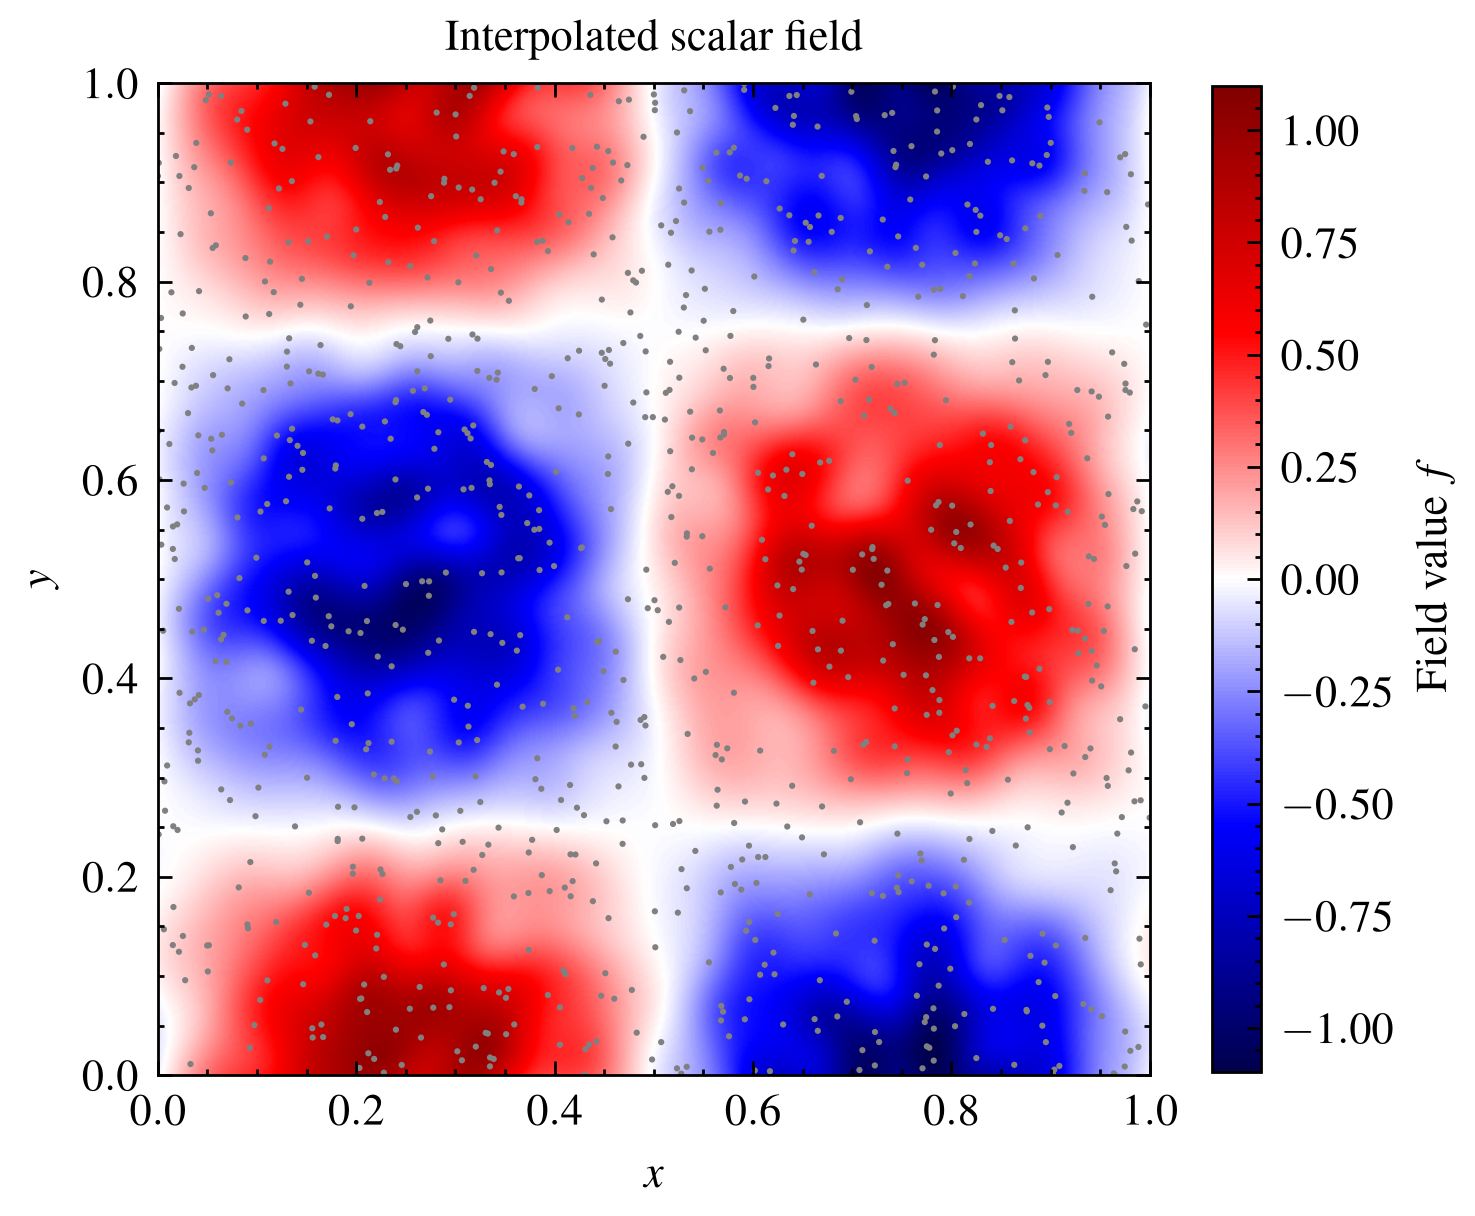

In [23]:
image = query_values[:, 0].reshape((nx, ny)).T

fig, ax = plt.subplots(figsize=(4, 4))
ax.set_title('Interpolated scalar field')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')

im = ax.imshow(image, origin='lower', extent=(0, boxsize, 0, boxsize), cmap='seismic',
               norm=colors.CenteredNorm())
ax.scatter(positions[:, 0], positions[:, 1], s=5, color='gray', edgecolors='none')
cax = plt.colorbar(im, ax=ax, shrink=0.8)
cax.set_label(r'Field value $f$')

plt.show()

## Interpolating gradients of a field

Gradients of fields can be computed similarly using the standard SPH expression for the gradient of a scalar field $f$:

$$
\nabla f(\mathbf{x}_i) = \sum_{j}^{n} \frac{w_j}{\rho_j} \, f_j \, \nabla W\big(\mathbf{x}_i - \mathbf{x}_j;\ h_j\big).
$$

To obtain gradients at the same query points, we can call {py:meth}`~smudgy.pointcloud.PointCloud.interpolate` with the argument `mode="gradient"` (`"field"` by default). The returned array has shape `(M, F, D)` where 
+ `M` is the number of query points, here = `nx * ny`
+ `F` is the number of fields, here = 1
+ `D` is the spatial dimension, here = 2

In [24]:
query_values_gradients = pc.interpolate(fields=[field_1, field_2, field_3],
                                               query_positions=query_positions,
                                               mode='gradient')  # shape = (nx*ny, 3, 2)
magnitudes = np.linalg.norm(query_values_gradients[:, 0], axis=-1)

[smudgy] Interpolating gradients of fields at query positions using isotropic 'cubic_spline' kernel


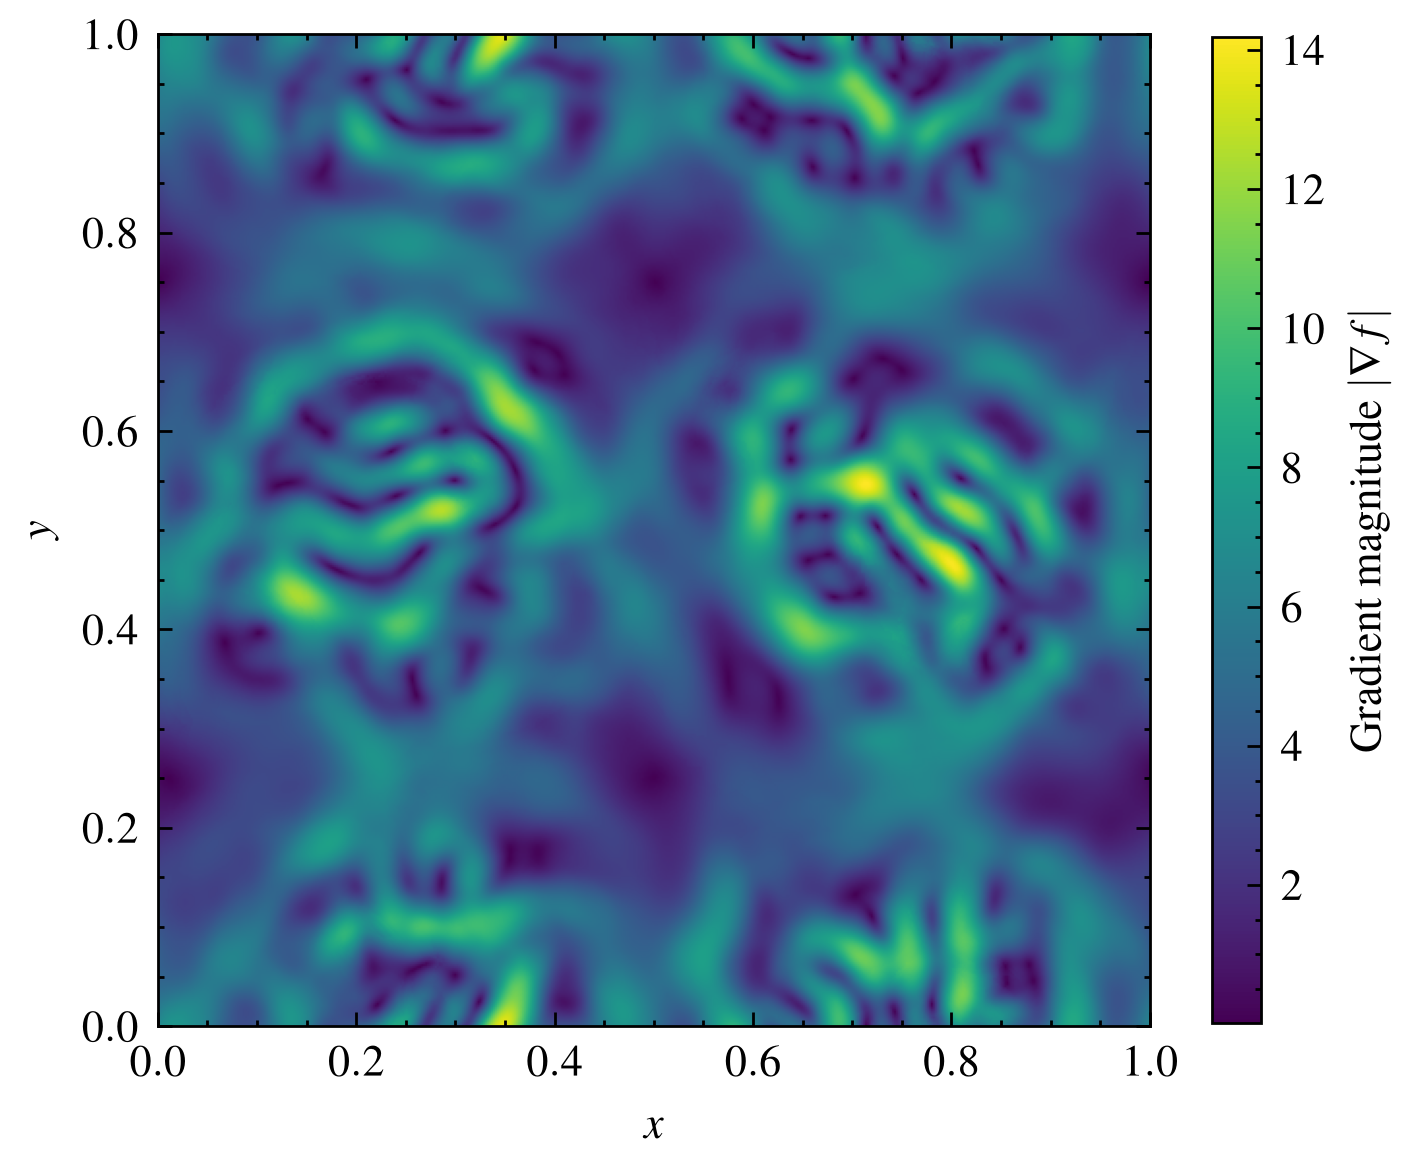

In [25]:
image = magnitudes.reshape((nx, ny)).T

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(image, origin='lower', extent=(0, boxsize, 0, boxsize), cmap='viridis')
cax = plt.colorbar(im, ax=ax, shrink=0.8)
cax.set_label(r'Gradient magnitude $|\nabla f|$')

ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')

plt.show()

## Interpolating the divergence and curl of vector fields

Suppose we have a single (or multiple) vector field $\mathbf{f}(\mathbf{x})$ associated with particles, e.g. velocity and angular momentum. With `smudgy`, we can interpolate those fields or compute their divergence and curl using the SPH formulations, i.e.

$$
(\nabla \cdot \mathbf{f})(\mathbf{x}_i) = \sum_j^n \frac{m_j}{\rho_j}
\mathbf{f}_j
\cdot
\nabla W\big(\mathbf{x}_i - \mathbf{x}_j;\ h_j\big)
$$

and

$$
(\nabla \times \mathbf{f})(\mathbf{x}_i) = \sum_j^n \frac{m_j}{\rho_j}
\mathbf{f}_j
\times
\nabla W\big(\mathbf{x}_i - \mathbf{x}_j;\ h_j\big).
$$

In [26]:
vector_field_1 = np.asarray(
    [np.sin(2 * np.pi * positions[:, 0]),
     np.cos(2 * np.pi * positions[:, 1])]
).T

vector_field_2 = -vector_field_1

In [27]:
pc.add_fields(
    names=['vector_field_1', 'vector_field_2'], 
    values=[vector_field_1, vector_field_2]
    )

Similar to the syntax for the scalr fields we can compute those quantities for multiple vector fields in a single unified call.

In [28]:
fields = pc.interpolate(fields=['vector_field_1', 'vector_field_2'],
                              query_positions=query_positions) # shape = (nx*ny, 4)

divergences = pc.interpolate(fields=['vector_field_1', 'vector_field_2'], 
                                    query_positions=query_positions,
                                    mode='divergence'
                                    ) # shape = (nx*ny, 2)

curls = pc.interpolate(fields=['vector_field_1', 'vector_field_2'], 
                              query_positions=query_positions, 
                              mode='curl'
                              ) # shape = (nx*ny, 2)

[smudgy] Interpolating fields at query positions using isotropic 'cubic_spline' kernel
[smudgy] Interpolating divergence of fields at query positions using isotropic 'cubic_spline' kernel
[smudgy] Interpolating curl of fields at query positions using isotropic 'cubic_spline' kernel


Note that similar to the scalar case, individual channels  of the vector fields are stacked in the last dimension. So, to access the interpolated vector field 1 we would do `interpolated_vf1 = fields[:, :2]`.

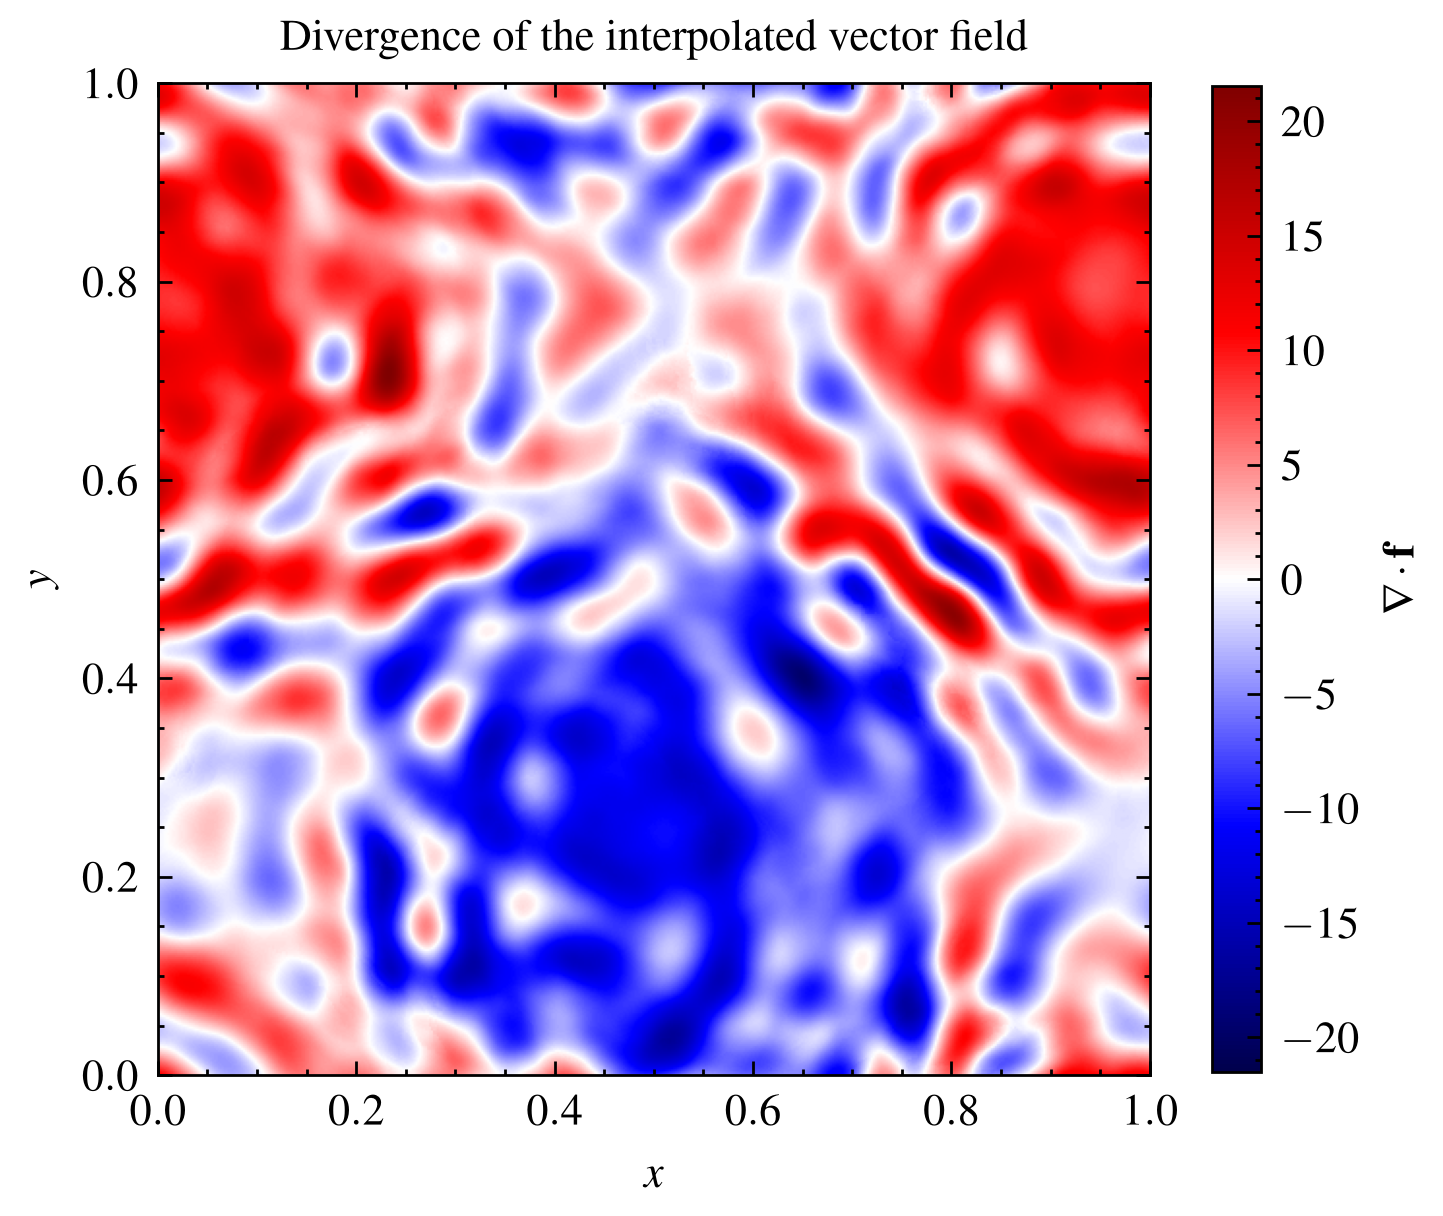

In [29]:
image = divergences[:, 0].reshape((nx, ny)).T

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(image, origin='lower', extent=(0, boxsize, 0, boxsize), cmap='seismic', norm=colors.CenteredNorm())
cax = plt.colorbar(im, ax=ax, shrink=0.8)
cax.set_label(r'$\nabla \cdot \mathbf{f}$')

ax.set_title('Divergence of the interpolated vector field')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')

plt.show()

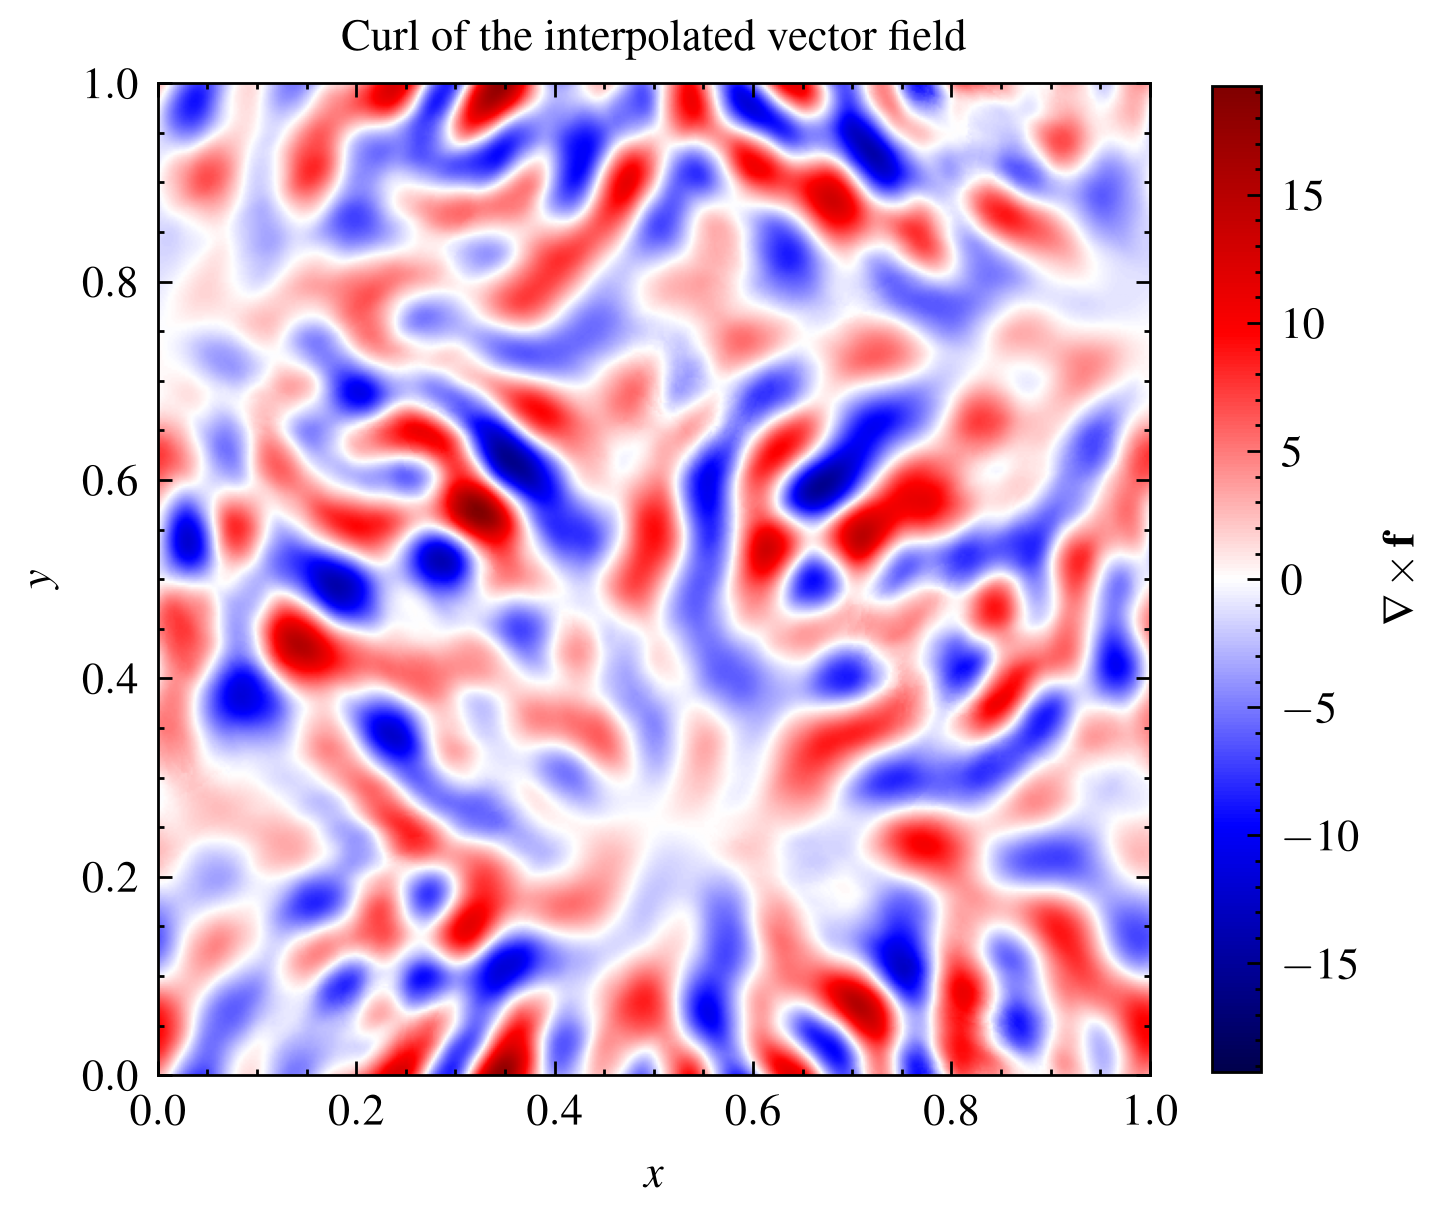

In [30]:
image = curls[:, 0].reshape((nx, ny)).T

fig, ax = plt.subplots(figsize=(4, 4))
im = ax.imshow(image, origin='lower', extent=(0, boxsize, 0, boxsize), cmap='seismic', norm=colors.CenteredNorm())
cax = plt.colorbar(im, ax=ax, shrink=0.8)
cax.set_label(r'$\nabla \times \mathbf{f}$')

ax.set_title('Curl of the interpolated vector field')
ax.set_xlabel(r'$x$')
ax.set_ylabel(r'$y$')

plt.show()